### Download and Transform Uncertainty data

#### Functions

In [1]:
import rasterio
from rasterio.enums import Resampling
import numpy as np
import numpy.matlib

def open_raster_file(file_path):
    """
    Opens a raster file
    
    Parameters:
        file_path (str): Path to the raster file.

    Returns:
        dataset: The opened rasterio dataset.
    """
    try:
        return rasterio.open(file_path)
    except IOError:
        print(f"Error opening file: {file_path}")
        raise

def resample_raster(src_file, resampling_method=Resampling.bilinear, upscale_factor=0.1):
    """
    Resamples a raster dataset.

    Parameters:
        dataset: Rasterio dataset to resample.
        resampling_method (rasterio.enums.Resampling): Method of resampling.
        upscale_factor (float): Factor to upscale the raster.

    Returns:
        Tuple containing resampled data array and new transform.
    """
    with rasterio.open(src_file) as dataset:
        print("Reading and resampling...")
        data = dataset.read(
            out_shape=(
                dataset.count,
                int(dataset.height * upscale_factor),
                int(dataset.width * upscale_factor)
            ),
            resampling=resampling_method
        )

        print("Scaling the transform...")
        transform = dataset.transform * dataset.transform.scale(
            (dataset.width / data.shape[-1]),
            (dataset.height / data.shape[-2])
        )

        print("Done")
        return data, transform

def write_raster_file(file_path, data, transform, crs, width, height, dtype):
    """
    Writes data to a raster file.

    Parameters:
        file_path (str): Path to save the raster file.
        data: Data array to be written.
        transform: Affine transform for the data.
        crs: Coordinate reference system for the data.
        width (int): Width of the output raster.
        height (int): Height of the output raster.
        dtype: Data type of the output raster.
    """
    with rasterio.open(
        file_path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype=dtype,
        crs=crs,
        transform=transform,
        nodata=None
    ) as dataset:
        dataset.write(data, 1)

def calculate_areas(lats, pix_width):
    """
    Calculate areas for each latitude in square kilometers.

    Parameters:
        lats (numpy.ndarray): Array of latitudes.
        pix_width (float): Pixel width in degrees.

    Returns:
        numpy.ndarray: Areas of cells in square kilometers.
    """
    a = 6378137
    b = 6356752.3142
    e = np.sqrt(1-(b/a)**2)
    sinlats = np.sin(lats * np.pi/180)
    zm = 1 - e * sinlats
    zp = 1 + e * sinlats
    q = pix_width / 360
    areas_to_equator = np.pi * b**2 * ((2*np.arctanh(e*sinlats) / (2*e) + sinlats / (zp*zm))) / 10**6
    areas_between_lats = np.diff(areas_to_equator)
    return np.abs(areas_between_lats) * q


def calculate_bounds(mean_arr, se_arr, z_score):
    """
    Calculate the lower and upper bounds of the 95% confidence interval.
    
    Parameters:
        mean_arr (numpy.ndarray): Array containing the mean values.
        se_arr (numpy.ndarray): Array containing the standard error values.
        z_score (float): The z-score corresponding to the confidence level.

    Returns:
        lower_bound (numpy.ndarray): Lower bound array with negative values set to 0.
        upper_bound (numpy.ndarray): Upper bound array.
    """
    lower_bound = mean_arr - (z_score * se_arr)
    upper_bound = mean_arr + (z_score * se_arr)

    # Replace negative values in lower_bound with 0
    lower_bound = np.maximum(lower_bound, 0)

    return lower_bound, upper_bound



#### File Path and Constants

In [2]:
# FILE PATHS
#INPUTS
#MODIS_LANDCOVER_RASTER = '../../data/processed/MCD12C1-2010-epsg.tif'
MODIS_LANDCOVER_RASTER = '../../data/processed/MODIS_high_confidence_grasslands.tif'
CARBON_BIOMASS_U_RASTER = "../../data/raw/Global_Maps_C_Density_2010_1763/data/aboveground_biomass_carbon_2010_uncertainty.tif"

#OUTPUTS
RESAMPLED_CARBON_BIOMASS_U_RASTER = "../../data/processed/biomass_u_resampled.tif"
GRASSLAND_BIOMASS_U_RASTER = "../../data/processed/biomass_u_mg_per_ha_from_grassland.tif"
GRASSLAND_BIOMASS_U_TONNES_RASTER = "../../data/processed/production_pit/biomass_from_grassland_u_tonnes.tif"
#GRASSLAND_BIOMASS_TONNES_RASTER = "../../data/processed/production_pit/biomass_from_grassland_tonnes.tif"
GRASSLAND_BIOMASS_TONNES_RASTER = "../../data/processed/production_pit/biomass_from_grassland_tonnes_highconfidence.tif"
GRASSLAND_BIOMASS_TONNES_UPPER_RASTER = "../../data/processed/production_pit/biomass_from_grassland_tonnes_upper.tif"
GRASSLAND_BIOMASS_TONNES_LOWER_RASTER = "../../data/processed/production_pit/biomass_from_grassland_tonnes_lower.tif"
BIOMASS_U_RESAMPLED_WARPED_BOUNDS = "../../data/processed/biomass_u_resampled_warped_bounds.tif"

# CONSTANTS
DOWNSCALE_FACTOR = 18
ABOVE_GROUND_CARBON_MASS_FRACTION_FOR_GRASSES = 0.4473
GRASS_VALUE = 10.0


#### Resampling Data

In [3]:
# Open and process MODIS landcover raster
landcover_dataset = open_raster_file(MODIS_LANDCOVER_RASTER)
landcover_array = landcover_dataset.read(1)

# Open and process carbon biomass uncertainty raster
carbon_biomass_u_dataset = open_raster_file(CARBON_BIOMASS_U_RASTER)
carbon_biomass_u_array = carbon_biomass_u_dataset.read(1)

# Check for nodata values in carbon biomass uncertainty array
carbon_nodata = carbon_biomass_u_array == 65536
print(f"Number of nodata values in carbon biomass uncertainty array: {carbon_nodata.sum()}")

# Re-sample the biomass raster to crop raster (down-scale by a factor of 18)
biomass_u_arr, biomass_u_transform = resample_raster(CARBON_BIOMASS_U_RASTER, Resampling.average, 1/DOWNSCALE_FACTOR)

# Save resampled data
biomass_u_dataset = rasterio.open(
    RESAMPLED_CARBON_BIOMASS_U_RASTER,
    "w",
    driver="GTiff",
    height=carbon_biomass_u_array.shape[0] / DOWNSCALE_FACTOR,
    width=carbon_biomass_u_array.shape[1] / DOWNSCALE_FACTOR,
    count=1,
    dtype= biomass_u_arr.dtype,
    crs='+proj=latlong',
    transform=biomass_u_transform
)


biomass_u_arr = np.squeeze(biomass_u_arr)

biomass_u_dataset.write(biomass_u_arr, 1)
biomass_u_dataset.close()


Number of nodata values in carbon biomass uncertainty array: 0
Reading and resampling...
Scaling the transform...
Done


In [4]:
print(carbon_biomass_u_array.max())
print(carbon_biomass_u_array.shape)
print((carbon_biomass_u_array.shape[0] * carbon_biomass_u_array.shape[1]) / (biomass_u_arr.shape[0] * biomass_u_arr.shape[1]) )
print(biomass_u_arr.sum())
print(carbon_biomass_u_array.sum() / 324.0062068965517)

36590
(52201, 129600)
324.0062068965517
544941579
12410631.208320828


In [4]:
# Warp resampled raster to match landcover raster bounds
# Note: requires GDAL command line tools

!rio warp "../../data/processed/biomass_u_resampled.tif" "../../data/processed/biomass_u_resampled_warped_bounds.tif" --overwrite --dst-crs EPSG:4326 --bounds -180 -90 180 90 --res 0.05

In [5]:
carbon_biomass_u_warped_dataset = open_raster_file(BIOMASS_U_RESAMPLED_WARPED_BOUNDS)
carbon_biomass_u_warped_array = carbon_biomass_u_warped_dataset.read(1)

# Create a boolean matrix of grass values
grassland = landcover_array == GRASS_VALUE

# Use only carbon biomass which corresponds to True values in the matrix
carbon_biomass_u_from_grassland_arr = grassland * carbon_biomass_u_warped_array

# Convert to biomass from carbon biomass
biomass_from_grassland_u_arr = carbon_biomass_u_from_grassland_arr / ABOVE_GROUND_CARBON_MASS_FRACTION_FOR_GRASSES

# Save processed grassland biomass data
write_raster_file(
    GRASSLAND_BIOMASS_U_RASTER,
    biomass_from_grassland_u_arr,
    carbon_biomass_u_dataset.transform,
    crs='+proj=latlong',
    height=biomass_from_grassland_u_arr.shape[0],
    width=biomass_from_grassland_u_arr.shape[1],
    dtype=biomass_from_grassland_u_arr.dtype
)

# Calculate raster grid cell areas
with open_raster_file(GRASSLAND_BIOMASS_U_RASTER) as dataset:
    transform = dataset.transform
    pix_width = transform[0]  # Pixel width in degrees
    ulY, lrY = transform[5], transform[5] + transform[4] * dataset.height
    lats = np.linspace(ulY, lrY, dataset.height + 1)

areas_cells = calculate_areas(lats, pix_width)

# Prepare the area grid for multiplication
areagrid = np.transpose(np.matlib.repmat(areas_cells, dataset.width, 1))

# Convert area grid from square km to hectares (x 100) and multiply by our "biomass tonnes per hectare" array
tonnes_of_biomass_from_grass_arr = biomass_from_grassland_u_arr * areagrid * 100

# Save the final biomass data in tonnes
write_raster_file(
    GRASSLAND_BIOMASS_U_TONNES_RASTER,
    tonnes_of_biomass_from_grass_arr,
    carbon_biomass_u_dataset.transform,
    crs='+proj=latlong',
    width=tonnes_of_biomass_from_grass_arr.shape[1],
    height=tonnes_of_biomass_from_grass_arr.shape[0],
    dtype=tonnes_of_biomass_from_grass_arr.dtype
)


In [6]:
print(biomass_from_grassland_u_arr.shape)
print(areagrid.shape)
print(areagrid.max())
print(areagrid.min())
print(tonnes_of_biomass_from_grass_arr.sum()*0.1) # convert units to Mg C/Ha

(3600, 7200)
(3600, 7200)
0.026503993978516948
0.010062948678056776
13650529.887685308


### Visualize Standard Errors

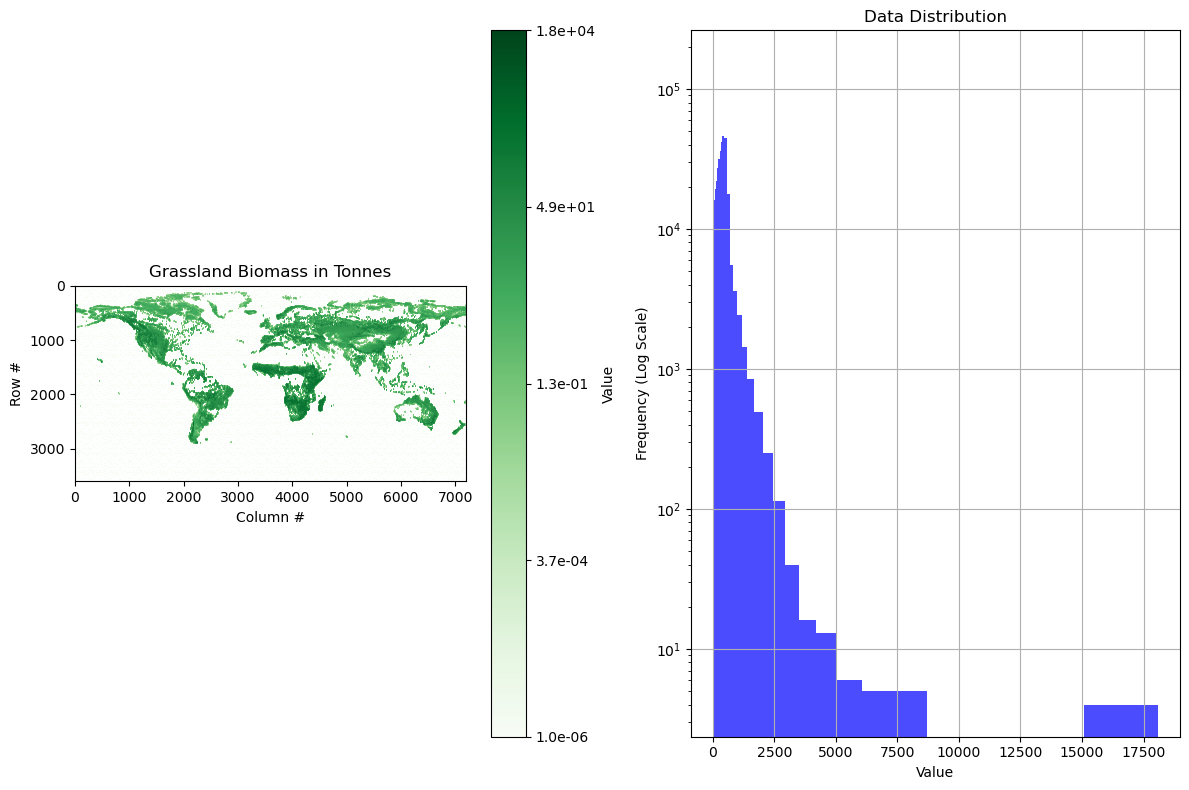

In [7]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma

def read_raster(file_path):
    """
    Reads a raster file and returns the data array and metadata.

    Parameters:
        file_path (str): Path to the raster file.

    Returns:
        Tuple containing the data array and metadata.
    """
    with rasterio.open(file_path) as dataset:
        data = dataset.read(1)
        metadata = dataset.meta
    return data, metadata

import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.colors as colors




def plot_raster(data, nodata_value, title='Raster Data', cmap='viridis'):
    """
    Plots the raster data using matplotlib, accounting for missing values.
    Includes a histogram of the data distribution.

    Parameters:
        data (numpy.ndarray): The raster data array.
        nodata_value: Value representing 'no data' in the raster dataset.
        title (str): Title of the plot.
        cmap (str): Color map for the plot.
    """
    
    masked_data = ma.masked_where(data == nodata_value, data)

    # Plot the raster data
    plt.figure(figsize=(12, 8))

    # Raster plot
    plt.subplot(1, 2, 1)

    
    vmin = max(masked_data.min(), masked_data.compressed().min(), 1e-6)  # Setting a very small positive vmin
    vmax = masked_data.max()

    # Use logarithmic scaling 
    if vmin > 0 and vmax > 0 and vmax / vmin > 1000:  # arbitrary threshold for using log scale
        norm = colors.LogNorm(vmin=vmin, vmax=vmax)
        plt.imshow(masked_data, cmap=cmap, norm=norm)
        cbar = plt.colorbar(label='Value')

        # Calculate the log-spaced ticks
        tick_values = np.geomspace(vmin, vmax, num=5)  # creates 5 logarithmically spaced ticks between vmin and vmax
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels(["{:.1e}".format(tick) for tick in tick_values])  # format ticks as scientific notation
    else:
        plt.imshow(masked_data, cmap=cmap)
        plt.colorbar(label='Value')
    plt.title(title)
    plt.xlabel('Column #')
    plt.ylabel('Row #')

    # Histogram
    plt.subplot(1, 2, 2)

    # Exclude zero values 
    valid_data = masked_data.compressed()
    valid_data = valid_data[valid_data != 0] 

    bins = np.logspace(np.log10(valid_data.min()), np.log10(valid_data.max()), 50)
    

    # Plot histogram with a logarithmic scale on the y-axis
    plt.hist(valid_data, bins=bins, color='blue', alpha=0.7, log=True)
    plt.title('Data Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency (Log Scale)')
    plt.grid(True)  

    plt.tight_layout()
    plt.show()


# Path to the raster file 
raster_file_path = '../../data/processed/production_pit/biomass_from_grassland_u_tonnes.tif'

# Read the raster data
raster_data, raster_metadata = read_raster(raster_file_path)

# Define the nodata value 
nodata_value = raster_metadata['nodata']

# Plot the raster data, accounting for missing values
plot_raster(raster_data, nodata_value, title='Grassland Biomass in Tonnes', cmap='Greens')



### Convert SEs to Lower and Upper Bound Biomass Data

In [8]:
# Open the existing datasets for mean and standard error
mean_dataset = rasterio.open(GRASSLAND_BIOMASS_TONNES_RASTER)
se_dataset = rasterio.open(GRASSLAND_BIOMASS_U_TONNES_RASTER)

# Read the datasets into arrays
mean_arr = mean_dataset.read(1)
se_arr = se_dataset.read(1)

# Mask NaN values in mean_arr
mean_arr_masked = np.ma.masked_where(np.isnan(mean_arr), mean_arr)

# Calculate the 95% confidence interval bounds
z_score = 1.96 
lower_bound, upper_bound = calculate_bounds(mean_arr_masked, se_arr, z_score)


write_raster_file(
    GRASSLAND_BIOMASS_TONNES_LOWER_RASTER,
    lower_bound,
    mean_dataset.transform,
    mean_dataset.crs,
    mean_dataset.width,
    mean_dataset.height,
    mean_arr.dtype
)

write_raster_file(
    GRASSLAND_BIOMASS_TONNES_UPPER_RASTER,
    upper_bound,
    mean_dataset.transform,
    mean_dataset.crs,
    mean_dataset.width,
    mean_dataset.height,
    mean_arr.dtype
)

# Close the datasets
mean_dataset.close()
se_dataset.close()


In [9]:
mean_arr.max()


287391.55288253527

In [10]:
transform = mean_dataset.transform

# Extract pixel dimensions (width and height)
pixel_width, pixel_height = transform[0], transform[4]

# Get the coordinate reference system
crs = mean_dataset.crs

In [11]:
print(f"Pixel Size: {pixel_width} by {pixel_height} in CRS units")
print(f"Coordinate Reference System: {crs}")

Pixel Size: 0.002777777777777778 by -0.0027777778203482693 in CRS units
Coordinate Reference System: GEOGCS["GRS 1980(IUGG, 1980)",DATUM["unknown",SPHEROID["GRS80",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]]


#### Visualize and Summarize Upper Bound and Lower Bound Data

##### Upper Bound

Summary Statistics:
Min: 4.708136824774054
Max: 287493.4802221382
Mean: 49361.57807970313
Median: 39191.44655955405
Standard Deviation: 38449.0877561193
Stum: 67045511511.49102


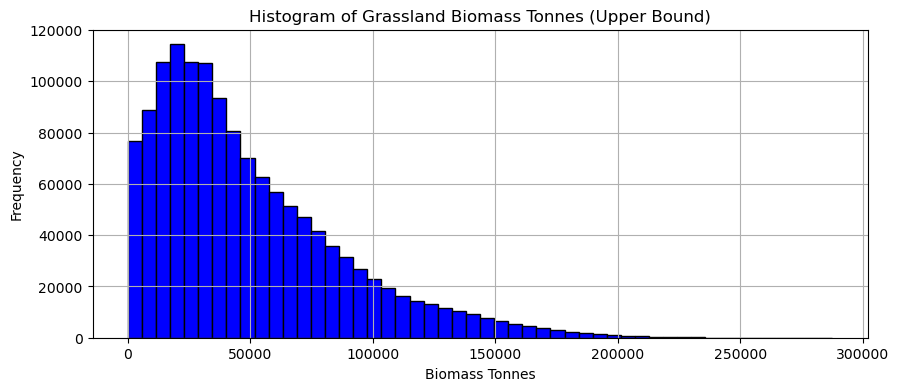

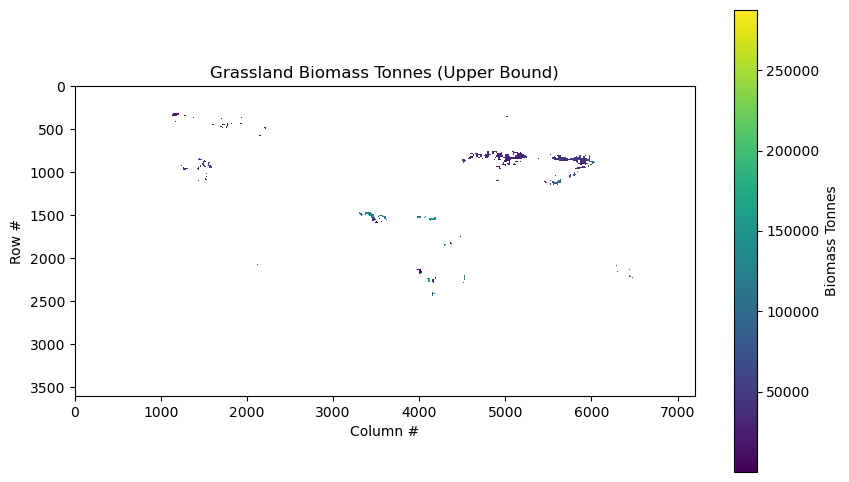

In [12]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Open the raster file
with rasterio.open(GRASSLAND_BIOMASS_TONNES_UPPER_RASTER) as src:
    data = src.read(1)

# Mask out NaNs, extreme values, and zeros
valid_range = (-1e30, 1e30)  
masked_data = np.ma.masked_where((data == 0) | ~np.isfinite(data) | (data < valid_range[0]) | (data > valid_range[1]), data)


# Recalculate summary statistics with the masked data
min_value = np.min(masked_data) 
max_value = np.max(masked_data) 
mean_value = np.mean(masked_data) 
median_value = np.ma.median(masked_data) 
std_dev = np.std(masked_data) 
sum = masked_data.sum()

# Summary statistics
print("Summary Statistics:")
print(f"Min: {min_value}")
print(f"Max: {max_value}")
print(f"Mean: {mean_value}")
print(f"Median: {median_value}")
print(f"Standard Deviation: {std_dev}")
print(f"Stum: {sum}")

# Histogram of the valid data
plt.figure(figsize=(10, 4))
hist_data = masked_data.compressed()  # Flatten and remove masked values for histogram
plt.hist(hist_data, bins=50, color='blue', edgecolor='black')
plt.title('Histogram of Grassland Biomass Tonnes (Upper Bound)')
plt.xlabel('Biomass Tonnes')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plotting the valid raster data
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap='viridis', vmin=min_value, vmax=max_value)
plt.colorbar(label='Biomass Tonnes')
plt.title('Grassland Biomass Tonnes (Upper Bound)')
plt.xlabel('Column #')
plt.ylabel('Row #')
plt.show()


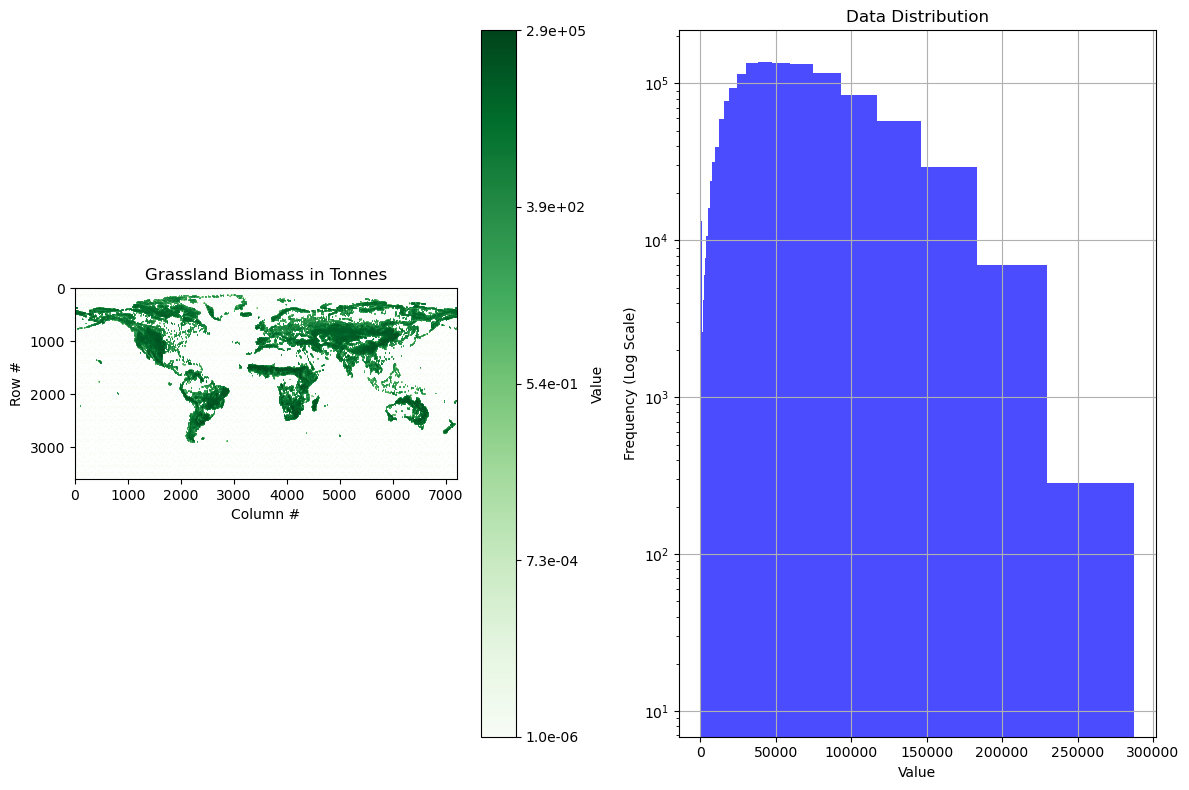

In [13]:
# Read the raster data
upper_data, upper_metadata = read_raster(GRASSLAND_BIOMASS_TONNES_UPPER_RASTER)

# Define the nodata value 
nodata_value = upper_metadata['nodata']

# Plot the raster data, accounting for missing values
plot_raster(upper_data, nodata_value, title='Grassland Biomass in Tonnes', cmap='Greens')

In [14]:
masked_data = ma.masked_where(upper_data == nodata_value, raster_data)
# Recalculate summary statistics with the masked data
min_value = np.min(masked_data) 
max_value = np.max(masked_data) 
mean_value = np.mean(masked_data) 
median_value = np.ma.median(masked_data) 
std_dev = np.std(masked_data) 
sum = masked_data.sum()

# Summary statistics
print("Summary Statistics:")
print(f"Min: {min_value}")
print(f"Max: {max_value}")
print(f"Mean: {mean_value}")
print(f"Median: {median_value}")
print(f"Standard Deviation: {std_dev}")
print(f"Stum: {sum}")

Summary Statistics:
Min: 0.0
Max: 18078.707187210894
Mean: 5.26640813568106
Median: 0.0
Standard Deviation: 47.9652908745025
Stum: 136505298.87685308


##### Lower Bound

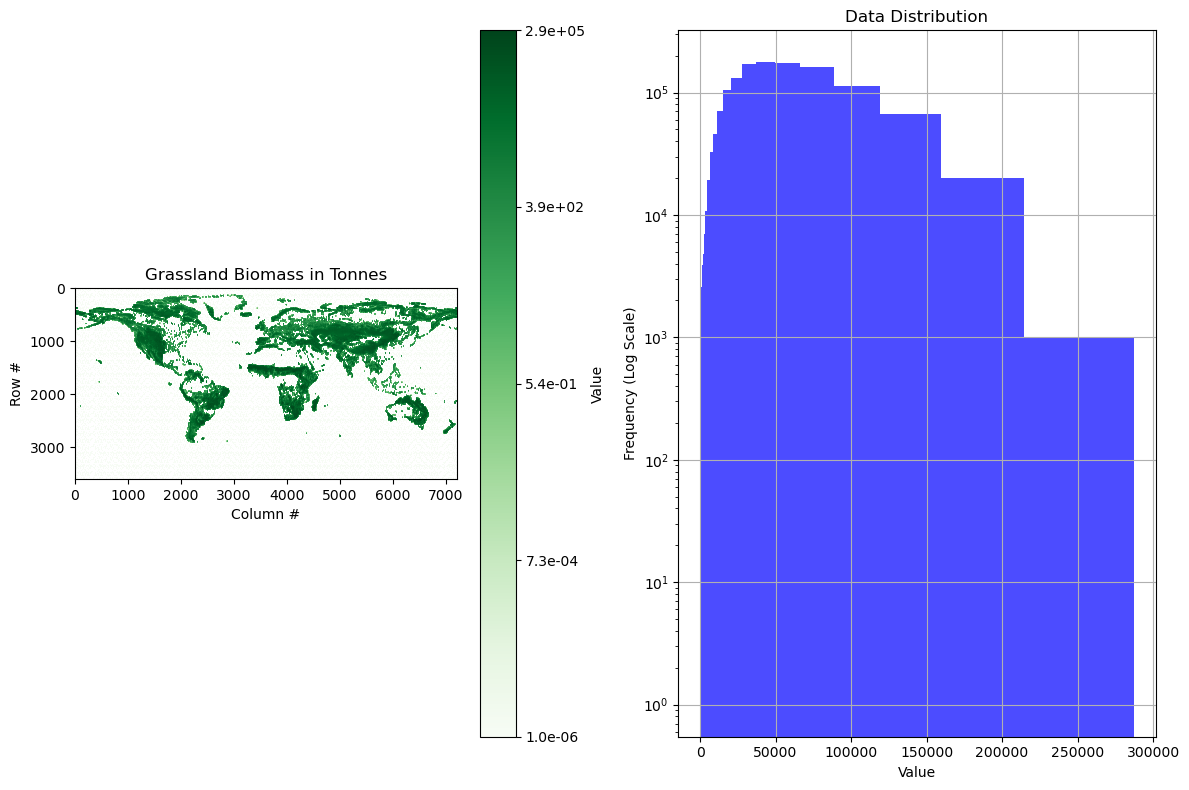

In [15]:
# Read the raster data
lower_data, lower_metadata = read_raster(GRASSLAND_BIOMASS_TONNES_LOWER_RASTER)

# Define the nodata value 
nodata_value = lower_metadata['nodata']

# Plot the raster data, accounting for missing values
plot_raster(lower_data, nodata_value, title='Grassland Biomass in Tonnes', cmap='Greens')

In [16]:
masked_data = ma.masked_where(raster_data == nodata_value, raster_data)
# Recalculate summary statistics with the masked data
min_value = np.min(masked_data) 
max_value = np.max(masked_data) 
mean_value = np.mean(masked_data) 
median_value = np.ma.median(masked_data) 
std_dev = np.std(masked_data) 
sum = masked_data.sum()

# Summary statistics
print("Summary Statistics:")
print(f"Min: {min_value}")
print(f"Max: {max_value}")
print(f"Mean: {mean_value}")
print(f"Median: {median_value}")
print(f"Standard Deviation: {std_dev}")
print(f"Stum: {sum}")

Summary Statistics:
Min: 0.0
Max: 18078.707187210894
Mean: 5.26640813568106
Median: 0.0
Standard Deviation: 47.9652908745025
Stum: 136505298.87685308


Summary Statistics:
Min: 0.16584641574172565
Max: 287289.6255429323
Mean: 50288.37720395056
Median: 40034.986070184714
Standard Deviation: 38167.150026097195
Stum: 66540021776.57406


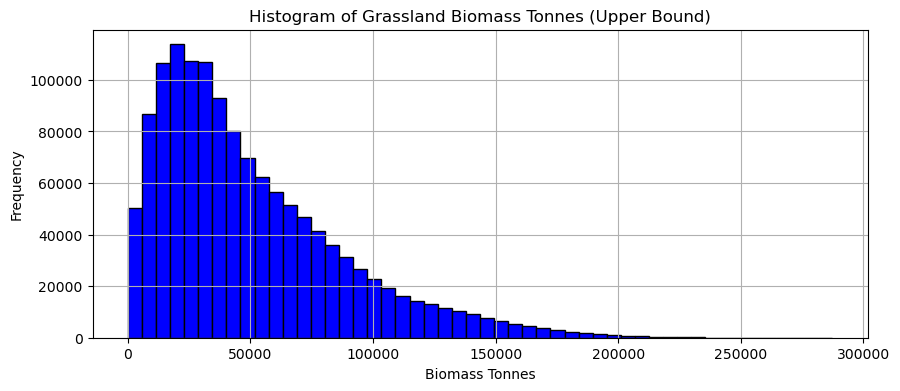

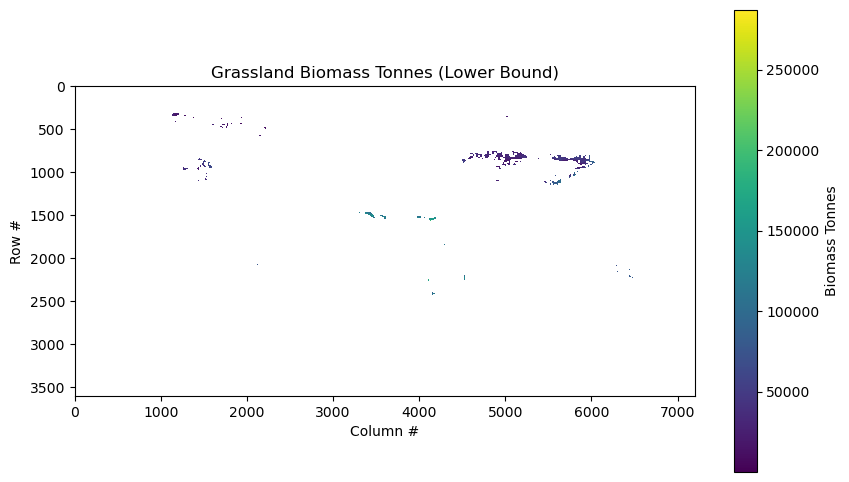

In [17]:
# Open the raster file
with rasterio.open(GRASSLAND_BIOMASS_TONNES_LOWER_RASTER) as src:
    data = src.read(1)

# Mask out NaNs, extreme values, and zeros
valid_range = (-1e30, 1e30)  # 
masked_data = np.ma.masked_where((data == 0) | ~np.isfinite(data) | (data < valid_range[0]) | (data > valid_range[1]), data)


# Recalculate summary statistics with the masked data
min_value = np.min(masked_data) 
max_value = np.max(masked_data) 
mean_value = np.mean(masked_data) 
median_value = np.ma.median(masked_data) 
std_dev = np.std(masked_data) 
sum = masked_data.sum()

# Summary statistics
print("Summary Statistics:")
print(f"Min: {min_value}")
print(f"Max: {max_value}")
print(f"Mean: {mean_value}")
print(f"Median: {median_value}")
print(f"Standard Deviation: {std_dev}")
print(f"Stum: {sum}")

# Histogram of the valid data
plt.figure(figsize=(10, 4))
hist_data = masked_data.compressed()  # Flatten and remove masked values for histogram
plt.hist(hist_data, bins=50, color='blue', edgecolor='black')
plt.title('Histogram of Grassland Biomass Tonnes (Upper Bound)')
plt.xlabel('Biomass Tonnes')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plotting the valid raster data
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap='viridis', vmin=min_value, vmax=max_value)
plt.colorbar(label='Biomass Tonnes')
plt.title('Grassland Biomass Tonnes (Lower Bound)')
plt.xlabel('Column #')
plt.ylabel('Row #')
plt.show()


### Summarize

In [18]:
#summarize
print(upper_bound.sum()*0.1)

6704551151.149102


In [19]:
print(lower_bound.sum()*0.1)

6654002177.657406


In [20]:
print('UPPER BOUND BIOMASS')

print('Total Crude Protein (megatonnes)')
print('less than 50:', ((upper_bound.sum()*0.1)/1000000) * 9.6/100)

print('\n')

print('Total RME (petajoules)')

print('less than 50:', ((upper_bound.sum()*0.1)/1000000) * 8.9)

print('\n')
print('\n')

print('LOWER BOUND BIOMASS')

print('Total Crude Protein (megatonnes)')
print('less than 50:', ((lower_bound.sum()*0.1)/1000000) * 9.6/100)

print('\n')

print('Total RME (petajoules)')

print('less than 50:', ((lower_bound.sum()*0.1)/1000000) * 8.9)

UPPER BOUND BIOMASS
Total Crude Protein (megatonnes)
less than 50: 643.6369105103138


Total RME (petajoules)
less than 50: 59670.50524522701




LOWER BOUND BIOMASS
Total Crude Protein (megatonnes)
less than 50: 638.7842090551109


Total RME (petajoules)
less than 50: 59220.619381150915
